# 第58篇 | LightGBM：更快更强的梯度提升

> 这是「数据分析从入门到精通」系列的第 58 篇。XGBoost 掌握了，这篇来学它的"进化版"——LightGBM。微软开源，速度更快、内存更省，特别适合大规模数据。如果 XGBoost 是核武器，LightGBM 就是光速核武器，工业界首选。

嗨，我是小荷～ 上篇了解了XGBoost，今天来学它的"升级版"：**LightGBM（Lightweight Gradient Boosting Machines）**！

---

## 一、LightGBM vs XGBoost

LightGBM 是微软推出的基于决策树的顶尖算法。如果说 XGBoost 是一个**追求完美、把每道错题都研究到极致的“严谨老司机”**，那么 LightGBM 就是一个**双商极高、懂得“抓大放小、抄近路走捷径”的“天才学神”**。

它之所以叫 **Light（轻量、快速）**，是因为它在 XGBoost 的基础上，觉得老司机的速度还是太慢了，于是决定在**找错题的思路**和**树的长势**上进行两项颠覆性的技术魔改。

**绝招一：纵向砍数值，直方图算法——划分“错题严重等级”**

假设一号老师交给你一本厚厚的错题本。每道错题旁边，老师都极其精准地标注了这道题你错了多少分（也就是残差/梯度）。因为有小数点，分数五花八门：这个题减0.1分，那个题扣了0.2分...最后这道扣了9.98分，现在，二号老师要从这 1 万道错题里切一刀，划分出“重灾区错题”和“轻微疏忽题”，从而决定把下一棵树的精力优先押在哪一类题上。

XGBoost 这种强迫症学生，会把这 1 万道错题按照分数的绝对大小，从 0.1 分到 9.98 分严格排个序。然后从第一个开始切，如果分数线定在0.125准确度是多少？如果切在第2个和第3个中间，准确度又是多少？为了找到那个最完美的“性价比切分点”，它要老老实实在夹缝里切 9999 刀。如果错题本上有几千万道题，这种地毯式搜索会把人当场逼疯。

LightGBM 这个学神看了一眼，觉得为了 0.01 分的差距去切一刀，纯粹是脑子开窍不够。
他一挥手：“别管那些零头了！我们直接在错题本里贴上 5 种颜色的标签分类口袋（大箱子 Bins），按亏分严重程度归档！”

- 错 0 - 2 分 $\rightarrow$ 扔进 “蚊子肉/轻微粗心”口袋（1号箱）
- 错 2 - 5 分 $\rightarrow$ 扔进 “基础不牢”口袋（2号箱）
- 错 5 - 8 分 $\rightarrow$ 扔进 “重点难点”口袋（3号箱）
- 错 8 - 10分 $\rightarrow$ 扔进 “核心大题”口袋（4号箱）
- 错 10分以上 $\rightarrow$ 扔进 “毁灭打击/完全不会”口袋（5号箱）

现在，二号老师要给错题划分类别、寻找最佳切分点时，再也不用去数那 1 万道题的排序了，它只需要在 5 个口袋的夹缝之间切上4刀就完事了。


**绝招二：纵向砍行数，GOSS 算法——只给“差生”补课（抓大放小）**

XGBoost 每次更新错题本时，都要把全班所有学生（所有数据样本）重新扫描一遍，这在数据量达到几千万甚至上亿时，电脑内存会直接累到冒烟。

LightGBM 跳出来说：“没必要！全班有 80% 的人已经掌握得差不多了（误差/一阶导数很小），剩下 20% 的差生（误差/一阶导数极大）才是拖后腿的。**我后面几轮补课，只盯着这 20% 的差生，剩下的优等生我直接忽略或者象征性抽样，不就省下大量时间了吗？**”

这就是 **GOSS（单边梯度采样）** 技术：

* 它保留所有大梯度的样本（算错得离谱的“死穴”）。
* 对小梯度的样本（已经算得挺准的数据）进行随机抽样。
* **结果**：数据量瞬间砍掉一大半，但模型关注的依然是最核心的“难点”，精准度几乎不降，速度却起飞了。

**绝招三：横向砍列数， EFB 技术——把“绝不碰面的孤僻特征”打包（特征降维）**

我们在做数据分析时，经常会遇到**独热编码（One-Hot Encoding）**，比如`职业`这一列，会拆成`是不是医生`、`是不是厨师`、`是不是程序员`。
这些特征有一个特点：**它们是互斥的**。一个人如果是医生，那他在厨师和程序员两列必然全是 **0**。这造成了数据表里有大量的“空气（稀疏矩阵）”。

XGBoost 找切分点时，会老老实实一列一列去扫描。
LightGBM 运用了类似 **“特征降维”** 的跨界思维，推出了 **EFB（互斥特征捆绑）**：
“既然你们几个特征绝不可能同时为 1，那我就把你们**打包、揉碎、融合成一列新特征**（比如一列叫`职业代号`，1是医生，2是厨师，3是程序员）。”

通过这个物理大打包，原本几千列的稀疏表格，被它瞬间浓缩，扫描特征的成本呈指数级下降。

**绝招四：树的长势魔改， Leaf-wise（按叶子长） vs Level-wise（按层长）**

这是 LightGBM 和 XGBoost 在外形上最直观的区别。

* **XGBoost（Level-wise，按层生长）**：
它是个规规矩矩的家长，树在长大时，**必须同一层的兄弟姐妹一起长**。哪怕左边这个叶子错得更严重、更需要分裂，也必须等右边那个已经挺完美的叶子陪着一起分裂。这种长法很稳，不容易过拟合，但浪费了算力。
* **LightGBM（Leaf-wise，按叶子生长）**：
它是一个绝对的**结果导向制**。它全场扫描，发现哪一个叶子的“分裂收益最大（最能降低错题误差）”，就**揪住这一个叶子疯狂往下狂飙**，让它一直长。至于其他已经很完美的叶子，对不起，直接“停工”。下面的3.2模块我们会详细讨论。
    * **带来的问题**：Leaf-wise 很容易把一根枝条长得极深，形成畸形树（也就是死记硬背的**过拟合**）。
    * **解法**：所以 LightGBM 必须强制配合一个参数 `max_depth`（最大深度），死死限高，不让它肆无忌惮地盲目长深。


**终极奥义：直接吃“类别特征”（Categorical Features）**

以前用 XGBoost 算数据，遇到`城市（北京/上海/广州）`这种文本特征，你必须小心翼翼地先在外面做 LabelEncoding 或 One-Hot，才能喂给模型。

LightGBM 内置了**直接吞噬类别特征**的超能力。你只需要在代码里指定 `categorical_feature=['city']`，它就会在底层用自己独特的高能直方图算法（Histogram-based），自动帮你寻找北京、上海、广州的最佳切分组合，不需要你再写一堆繁琐的预处理代码。

**总结：LightGBM 的极简画像**

如果说 XGBoost 是靠极致的数学严谨度（二阶展开、每层必扫）**稳打稳扎；那么 LightGBM 就是靠**天才的工程偷懒（GOSS抽样、EFB特征打包、Leaf-wise挑重点长）实现降本增效。

* **什么时候用 XGBoost**：数据量中小，追求极高的稳定性和防御过拟合能力，对时间不敏感。
* **什么时候用 LightGBM**：海量数据（几十万行以上），内存有限，需要疯狂刷榜打比赛，或者要求模型秒级更新。

---

## 二、速度对比：LightGBM vs XGBoost

下面我们在完全相同超参数（树数量、树深度、随机种子统一）的前提下，对比 XGBoost 与 LightGBM 两大梯度提升树模型：
- 统计各自完整训练耗时；
- 计算两者在同一测试集上的预测准确率；
- 量化输出 LightGBM 相对 XGBoost 的训练提速倍数，直观体现两者性能差异。：

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("⚡ LightGBM 极速梯度提升")
print("="*60)

# 生成数据
np.random.seed(42)
X, y = make_classification(n_samples=10000, n_features=50, n_informative=30,
                           n_redundant=10, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")


⚡ LightGBM 极速梯度提升
训练集: (8000, 50)
测试集: (2000, 50)


In [2]:
import time

print("\n训练速度对比:")
print("=" * 60)

# ---------------------- XGBoost 训练测速 ----------------------
print("\nXGBoost训练...")
# 初始化XGBoost二分类模型
xgb_model = xgb.XGBClassifier(n_estimators=100,  # n_estimators=100：100棵决策树
                              max_depth=6,  # max_depth=6：单树最大深度6
                              random_state=42, 
                              eval_metric='logloss' # eval_metric='logloss'：训练采用对数损失作为评估指标
                             )

# 记录训练开始时间戳
start_time = time.time()
# 使用训练集拟合模型
xgb_model.fit(X_train, y_train)
# 当前时间 - 开始时间 = 总训练耗时（单位：秒）
xgb_time = time.time() - start_time

# 在测试集完成预测
xgb_pred = xgb_model.predict(X_test)
# 计算测试集准确率
xgb_acc = accuracy_score(y_test, xgb_pred)

# 打印XGBoost耗时与精度，耗时保留3位小数
print(f"  训练时间: {xgb_time:.3f}秒")
print(f"  测试准确率: {xgb_acc:.4f}")

# ---------------------- LightGBM 训练测速 ----------------------
print("\nLightGBM训练...")
# 初始化LightGBM分类器，超参和XGB保持一致，保证公平对比
# verbose=-1：关闭训练日志输出，减少无关打印干扰计时
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=6, random_state=42, verbose=-1)

# 重置计时起点
start_time = time.time()
# 训练LightGBM模型
lgb_model.fit(X_train, y_train)
# 计算LightGBM训练总耗时
lgb_time = time.time() - start_time

# 测试集预测
lgb_pred = lgb_model.predict(X_test)
# 计算LightGBM测试准确率
lgb_acc = accuracy_score(y_test, lgb_pred)

print(f"  训练时间: {lgb_time:.3f}秒")
print(f"  测试准确率: {lgb_acc:.4f}")

# ---------------------- 汇总对比输出 ----------------------
print("\n" + "=" * 60)
# 计算速度倍数：XGB耗时 ÷ LGB耗时，数值越大代表LGB越快
print(f"速度提升: {xgb_time / lgb_time:.1f}倍")
# 同时打印两个模型的测试准确率，直观对比精度差距
print(f"准确率对比: XGBoost={xgb_acc:.4f}, LightGBM={lgb_acc:.4f}")



训练速度对比:

XGBoost训练...
  训练时间: 0.473秒
  测试准确率: 0.9540

LightGBM训练...
  训练时间: 0.103秒
  测试准确率: 0.9365

速度提升: 4.6倍
准确率对比: XGBoost=0.9540, LightGBM=0.9365


结论：
- LightGBM 基于直方图分箱、按叶子生长等优化，训练速度远快于 XGBoost，通常提速几倍至十几倍；
- 同等基础参数下两者准确率非常接近，精度差距极小；
- 数据量大、训练耗时敏感场景优先选用 LightGBM；需要精细自定义损失、高度自定义树规则时选用 XGBoost。

---

## 三、LightGBM核心原理

**（枯燥警告，保持清醒 😄😄）**

### 3.1 直方图算法

LightGBM 的速度优势来自直方图算法，关于直方图算法在第一节有介绍过，忘了的可以回头再看一下。这里再提一下直方图分箱带来的超级外挂---直方图做差。

假设你已经统计好了“整本数学错题本”（父亲节点）里 5 个口袋各自装了多少道题。
现在，你要把错题本拆成两部分研究：“代数章节的错题”（左儿子） 和 “几何章节的错题”（右儿子）。
- 普通人的做法：翻开代数部分，数数各个口袋有几题；再翻开几何部分，把 5 个口袋又数一遍。
- LightGBM 的做法：它只去数代数章节（左儿子）的口袋数量。数完之后，直接用【整本错题本的口袋数量】 减去 【代数章节的口袋数量】，一秒钟都没花，瞬间就秒出了【几何章节（右儿子）】的错题分布！


传统GBDT/XGBoost:
  - 对每个特征的每个可能分裂点计算增益
  - 时间复杂度: O(#data × #features)

LightGBM直方图算法:
  - 将连续特征离散化为k个bin（默认255）
  - 在bin上计算增益
  - 时间复杂度: O(#bin × #features)
  - 内存占用更小，缓存命中率更高

优势:
  - 计算速度快
  - 内存占用低
  - 对大规模数据友好
  

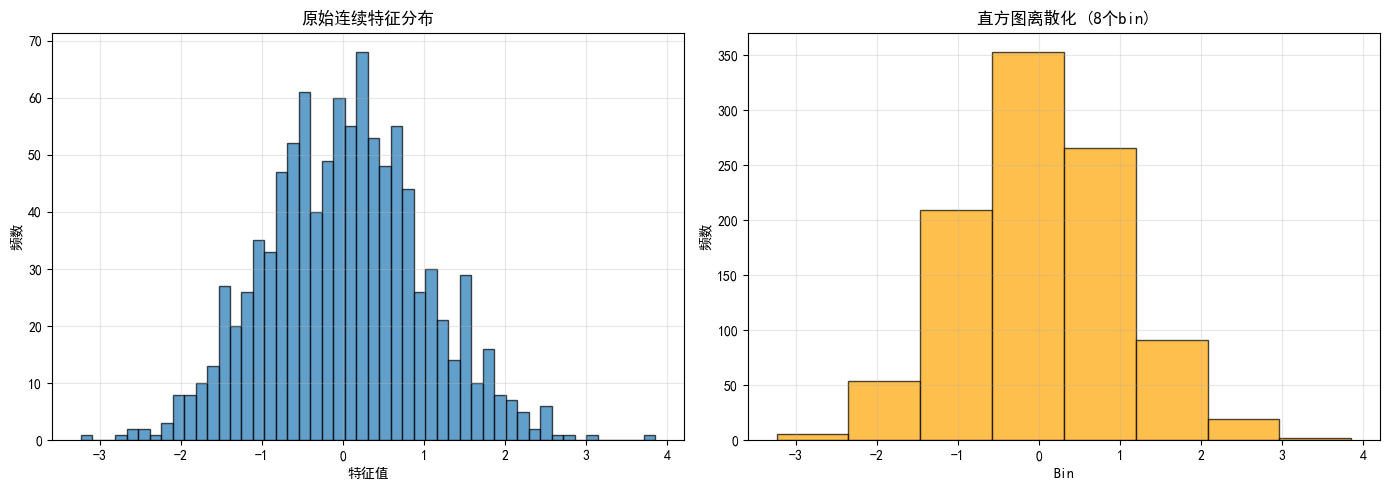

In [3]:
# 可视化直方图算法
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 原始连续特征
np.random.seed(42)
feature_values = np.random.randn(1000)

axes[0].hist(feature_values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('特征值')
axes[0].set_ylabel('频数')
axes[0].set_title('原始连续特征分布')
axes[0].grid(True, alpha=0.3)

# 离散化后的直方图
axes[1].hist(feature_values, bins=8, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Bin')
axes[1].set_ylabel('频数')
axes[1].set_title('直方图离散化 (8个bin)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 3.2 GOSS 算法


假设你现在手里有 **10 个样本（数据点）**，在上一轮决策树训练完后，每个样本都留下了不同的“错题程度”（我们用 **|梯度|（Gradient）** 的绝对值来代表它错得有多离谱）。

现在，LightGBM 要设置两个超参数来控制 GOSS 的采样：

* **$a = 0.2$**：代表保留 **20%** 错得最惨的“绝对差生”（大梯度样本）。
* **$b = 0.3$**：代表在剩下的“优等生”（小梯度样本）中，随机抽取 **30%** 出来当代表。

**1. 初始沙盘：10个样本的梯度大排队**

算法第一步，先把这 10 个样本按照 |梯度| 从大到小排个序：

```
样本ID:    [ 1,   2,   3,   4,   5,   6,   7,   8,   9,  10 ]
|梯度|:    [ 9.5, 8.8, 2.1, 1.8, 1.5, 1.2, 0.9, 0.6, 0.5, 0.2 ]
           |--- 差生区 ---| |-------------- 优等生区 --------------|
```

**2. GOSS 执行：两级分化采样**

**第一步：切出“顶级差生” （Top $a \times 100\%$）**

根据 $a = 0.2$，我们需要无条件保留前 $10 \times 0.2 = \mathbf{2}$ 个样本。

* **保留对象**：样本 1（梯度 9.5）和 样本 2（梯度 8.8）。
* **处理方式**：完好无损地带入下一轮，**权重保持为 1**。

**第二步：从“优等生”里抽样 （Sample $b \times 100\%$）**

剩下还有 8 个样本（样本 3 到 10），它们错得不严重。根据 $b = 0.3$，我们要从中随机摇号抽 $8 \times 0.3 \approx \mathbf{2}$ 个样本。

* **假设摇号摇中了**：样本 4（梯度 1.8）和 样本 7（梯度 0.9）。
* **剩下没抽中的 6 个样本怎么办？**：对不起，直接**无情淘汰，不参与本轮计算**。

**第三步：核心魔法——给幸存的优等生“撑腰”（放权）**

如果你直接把那 6 个没抽中的人扔了，整个数据的分布就变了（小梯度数据的信息被低估了）。
为了补偿这部分损失，GOSS 会给抽中的优等生乘以一个**放大系数**：

$$\text{放大系数} = \frac{1 - a}{b} = \frac{1 - 0.2}{0.3} = \frac{0.8}{0.3} = \mathbf{2.67}$$

所以，样本 4 和样本 7 的梯度在计算时，会增幅为原来的 2.67 倍！用来代表它们背后那 6 个被淘汰的同伴。

**3. 可视化沙盘：GOSS 采样前后对比图**

我们用一张直观的流程图，把这 10 个数据点的命运可视化出来：

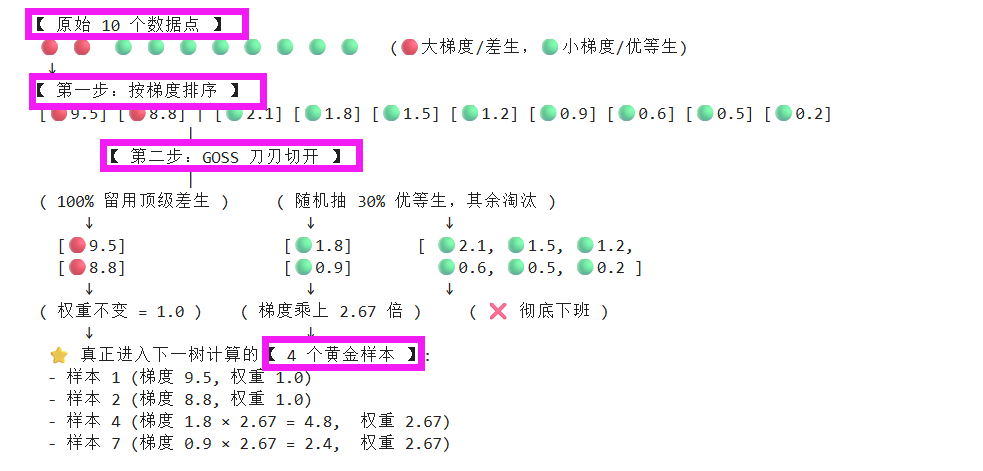

```
【 原始 10 个数据点 】
 🔴 🔴  🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢   (🔴大梯度/差生，🟢小梯度/优等生)
  ↓
【 第一步：按梯度排序 】
 [🔴9.5] [🔴8.8] | [🟢2.1] [🟢1.8] [🟢1.5] [🟢1.2] [🟢0.9] [🟢0.6] [🟢0.5] [🟢0.2]
                 |
        【 第二步：GOSS 刀刃切开 】
                 |
 ( 100% 留用顶级差生 )     ( 随机抽 30% 优等生，其余淘汰 )
      ↓                       ↓              ↓
   [🔴9.5]                 [🟢1.8]       [ 🟢2.1, 🟢1.5, 🟢1.2, 
   [🔴8.8]                 [🟢0.9]         🟢0.6, 🟢0.5, 🟢0.2 ] 
      ↓                       ↓              ↓
 ( 权重不变 = 1.0 )    ( 梯度乘上 2.67 倍 )     ( ❌ 彻底下班 )
      ↓                       ↓
  ⭐ 真正进入下一树计算的【 4 个黄金样本 】:
  - 样本 1 (梯度 9.5, 权重 1.0)
  - 样本 2 (梯度 8.8, 权重 1.0)
  - 样本 4 (梯度 1.8 × 2.67 = 4.8,  权重 2.67)
  - 样本 7 (梯度 0.9 × 2.67 = 2.4,  权重 2.67)
```

**为什么这样做能行？（可视化背后的数学直觉）**

如果用图形来理解，原本你要在一张密密麻麻装了 10 个点的复杂的误差曲面上找方向。
通过 GOSS 降维采样后：

1. **陡峭的悬崖（大梯度点）** 被原封不动地保留了，因为它们最危险、最需要被修正。
2. **平缓的平原（小梯度点）** 变得稀疏了（8个点变成了2个点），但是这两个点的“骨架”被放大了 2.67 倍，在曲面上撑起了和原本一模一样的平缓地势。

**最终结果**：LightGBM 只用了 **40% 的计算量**（4个点），就完美模拟了原先 10 个点才能画出来的误差曲面形状！这就是 LightGBM 在海量数据下跑得飞快的底层秘诀。



### 3.3 叶子优先生长

叶子优先生长策略，是 LightGBM 快的另一个秘密：

传统层级生长 (Level-wise):
  - 每层所有叶子一起分裂
  - 可能分裂增益很小的叶子
  - 树更平衡，但效率低

LightGBM叶子优先 (Leaf-wise):
  - 每次选择增益最大的叶子分裂
  - 更高效，但可能过拟合
  - 需要控制max_depth

图示对比:

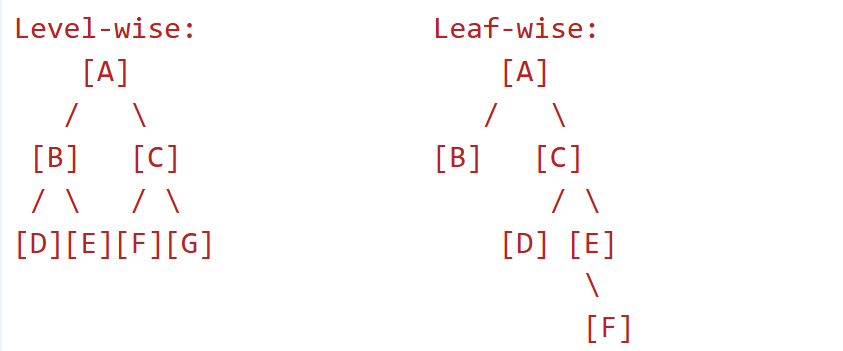


下面我们用 Python 写一段模拟LightGBM在底层“挑选并分裂叶子”的动画/日志演示代码。

这段代码模拟了算法在做决策时，如何冷酷地抛弃“按层生长（Level-wise）”的辈分观念，谁的误差降得多（性价比高），就让谁疯狂超生。

In [10]:
import time


class LeafNode:

    def __init__(self, node_id, depth, val_reduction):
        self.node_id = node_id
        self.depth = depth
        # 模拟这个叶子如果分裂，能够为模型降低多少误差（即：二阶导数性价比/分裂收益）
        self.val_reduction = val_reduction
        self.left = None
        self.right = None
        self.is_leaf = True

    def __repr__(self):
        return f"[Node_{self.node_id} (收益:{self.val_reduction})]"


class LeafWiseTreeDemo:

    def __init__(self, max_leaves=7, max_depth=5):
        self.max_leaves = max_leaves
        self.max_depth = max_depth
        self.root = LeafNode(node_id=0, depth=0, val_reduction=100)
        self.leaves = [self.root]  # 当前树拥有的所有活跃叶子节点
        self.node_counter = 0

    def grow_tree(self):
        print(f"🌲 开始 Leaf-wise 树生长演练 (最大叶子数:{self.max_leaves}, 限制最大深度:{self.max_depth})")
        print("=" * 70)

        # 只要叶子总数没达到上限，就一直挑“最肥”的叶子分裂
        while len(self.leaves) < self.max_leaves:
            time.sleep(1)  # 稍微停顿，制造动画效果

            # 【核心逻辑】：Leaf-wise 全场扫描，只挑分裂收益（val_reduction）最大的那一个叶子！
            # 不管它在哪一层，不管它的兄弟节点长没长！
            best_leaf = max(self.leaves, key=lambda x: x.val_reduction)

            # 安全带检查：如果达到了最大深度，这个叶子不准再长了
            if best_leaf.depth >= self.max_depth:
                print(
                    f"⚠️ 触发安全带！[Node_{best_leaf.node_id}] 已达到最大深度 {self.max_depth}，强行锁死！"
                )
                # 为了防止死循环，把它的收益清零，退出本次竞争
                best_leaf.val_reduction = -1
                continue

            print(
                f"\n🔥 轮到它了！全场扫描发现分裂收益最大的是: {best_leaf}，位于第 {best_leaf.depth} 层。"
            )

            # 从活跃叶子列表中移除它（因为它要变成枝干了）
            self.leaves.remove(best_leaf)
            best_leaf.is_leaf = False

            # 模拟给它分裂出左右两个新叶子，并随机赋予它们不同的“未来分裂收益”
            self.node_counter += 1
            # 左孩子模拟一个极高收益（高难度错题重灾区）
            left_reduction = int(best_leaf.val_reduction * 0.8)
            best_leaf.left = LeafNode(
                node_id=self.node_counter,
                depth=best_leaf.depth + 1,
                val_reduction=left_reduction,
            )

            self.node_counter += 1
            # 右孩子模拟一个极低收益（平缓简单的粗心题）
            right_reduction = int(best_leaf.val_reduction * 0.2)
            best_leaf.right = LeafNode(
                node_id=self.node_counter,
                depth=best_leaf.depth + 1,
                val_reduction=right_reduction,
            )

            # 把新生成的两个孩子加入到活跃叶子池中，等待下一轮筛选
            self.leaves.append(best_leaf.left)
            self.leaves.append(best_leaf.right)

            # 打印当前树的结构
            print(f"📊 当前活跃的叶子候选池: {self.leaves}")
            print("🌱 当前树的几何形状:")
            self._print_tree(self.root)
            print("-" * 50)

    def _print_tree(self, node, indent=""):
        """辅助函数：用符号在控制台画出树的形状"""
        if node is None:
            return
        if node.is_leaf:
            print(
                f"{indent}└── 🍃 [叶子_{node.node_id}] (深度:{node.depth}, 预估下次收益:{node.val_reduction})"
            )
        else:
            print(f"{indent}├── 🌿 [节点_{node.node_id}]")
            self._print_tree(node.left, indent + "    │")
            self._print_tree(node.right, indent + "    ")


# 执行演示
demo = LeafWiseTreeDemo(max_leaves=6, max_depth=4)
demo.grow_tree()

🌲 开始 Leaf-wise 树生长演练 (最大叶子数:6, 限制最大深度:4)

🔥 轮到它了！全场扫描发现分裂收益最大的是: [Node_0 (收益:100)]，位于第 0 层。
📊 当前活跃的叶子候选池: [[Node_1 (收益:80)], [Node_2 (收益:20)]]
🌱 当前树的几何形状:
├── 🌿 [节点_0]
    │└── 🍃 [叶子_1] (深度:1, 预估下次收益:80)
    └── 🍃 [叶子_2] (深度:1, 预估下次收益:20)
--------------------------------------------------

🔥 轮到它了！全场扫描发现分裂收益最大的是: [Node_1 (收益:80)]，位于第 1 层。
📊 当前活跃的叶子候选池: [[Node_2 (收益:20)], [Node_3 (收益:64)], [Node_4 (收益:16)]]
🌱 当前树的几何形状:
├── 🌿 [节点_0]
    │├── 🌿 [节点_1]
    │    │└── 🍃 [叶子_3] (深度:2, 预估下次收益:64)
    │    └── 🍃 [叶子_4] (深度:2, 预估下次收益:16)
    └── 🍃 [叶子_2] (深度:1, 预估下次收益:20)
--------------------------------------------------

🔥 轮到它了！全场扫描发现分裂收益最大的是: [Node_3 (收益:64)]，位于第 2 层。
📊 当前活跃的叶子候选池: [[Node_2 (收益:20)], [Node_4 (收益:16)], [Node_5 (收益:51)], [Node_6 (收益:12)]]
🌱 当前树的几何形状:
├── 🌿 [节点_0]
    │├── 🌿 [节点_1]
    │    │├── 🌿 [节点_3]
    │    │    │└── 🍃 [叶子_5] (深度:3, 预估下次收益:51)
    │    │    └── 🍃 [叶子_6] (深度:3, 预估下次收益:12)
    │    └── 🍃 [叶子_4] (深度:2, 预估下次收益:16)
    └── 🍃 [叶子_2] (深度:1, 预估下次收益:20)
------------

代码拆解：
1. `max(self.leaves, key=lambda x: x.val_reduction)`：这就是 Leaf-wise 的灵魂！普通的 XGBoost（Level-wise）是按层长，第一层长完了才能长第二层。而这里，LightGBM 直接放眼全树所有的叶子，不管你在哪一层、长得多深，谁的 val_reduction（二阶导数带来的误差下降收益）最大，谁就立刻分裂。
2. 畸形长势与 max_depth 安全带：在演示中你会发现，因为左边分裂出来的孩子（叶子 1 $\rightarrow$ 叶子 3）收益一直很高，算法会揪住左边这一根树枝一路疯狂往下死磕，而右边的“叶子 2”由于收益低，自始至终被冷落。这就是为什么 Leaf-wise 速度极快（直击痛点），但必须配合代码里的 max_depth 限制，否则它能把一根枝条长到天荒地老（过拟合）。

---

## 四、LightGBM基础使用

上面的理论比较抽象，咱们先上手跑通，再慢慢理解。

下面的代码展示了 LightGBM 的两种核心使用方式：面向 Scikit-Learn 生态的“高层封装 API”和面向极致性能与灵活性的“底层原生 API”。

代码的核心步骤：

1. 高层封装 API（Scikit-Learn 风格）
   - 使用 LGBMClassifier 构建分类器，并配置了核心参数。其中 num_leaves（叶子节点数）是 LightGBM 区别于 XGBoost 的最关键参数，LightGBM 采用“叶子生长（Leaf-wise）”策略，通过限制叶子节点数量来控制模型复杂度。
   - 采用与 Sklearn 完全一致的 .fit() 和 .predict() 语法，快速完成模型训练，并输出预测标签与预测概率
3. 底层原生 API（极致灵活与性能）
   - 使用 lgb.Dataset 将数据转换为 LightGBM 内部的专属数据结构。这种结构支持直方图算法和高效的内存管理，是 LightGBM 训练速度极快的基础。
   - 将 Sklearn 风格的参数转换为 LightGBM 原生字典参数（如 colsample_bytree 对应 feature_fraction，subsample 对应 bagging_fraction）
   - 使用 lgb.train() 进行训练，并原生集成了回调函数（Callbacks）
   - 在底层 API 预测时，显式指定了 num_iteration=model.best_iteration，确保使用早停机制找到的最优树数量进行预测，避免过拟合

In [5]:
# 打印标题，区分LightGBM基础使用模块
print("\nLightGBM基础使用:")
print("=" * 60)

# ===================== Sklearn风格高层API =====================
# 初始化LightGBM分类器，封装好的简易接口，上手简单
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,        # 迭代树总数量，一共训练100棵决策树
    max_depth=6,             # 单棵树最大深度，限制模型复杂度防过拟合
    learning_rate=0.1,       # 学习率，梯度下降更新权重的步长
    num_leaves=31,           # 单棵树最大叶子节点数，LightGBM核心复杂度参数
    subsample=0.8,           # 每棵树随机采样80%样本，对应原生参数bagging_fraction
    colsample_bytree=0.8,    # 每棵树随机采样80%特征，对应原生参数feature_fraction
    random_state=42,         # 固定随机种子，保证实验结果可复现
    verbose=-1               # 关闭训练过程打印日志，控制台更干净
)

# 在训练集上拟合模型
lgb_clf.fit(X_train, y_train)

# 模型预测分类标签（0/1）
y_pred = lgb_clf.predict(X_test)
# 预测正类概率，predict_proba输出[负类概率,正类概率]，取第二列
y_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

# 计算并打印测试集准确率，保留4位小数
print(f"测试准确率: {accuracy_score(y_test, y_pred):.4f}")

# ===================== LightGBM底层原生Train API =====================
# 底层API自由度更高，支持早停、自定义损失、自定义评估指标等高级功能
print("\n使用底层API:")
print("-" * 40)

# 构造LightGBM专属Dataset数据结构，训练速度更快、内存优化更好
train_data = lgb.Dataset(X_train, label=y_train)
# 构造验证集Dataset，reference绑定训练集，保证特征归一、类别对齐
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 模型训练超参数字典（原生API专用参数）
params = {
    'objective': 'binary',          # 任务目标：二分类
    'metric': 'binary_logloss',     # 训练监控指标：二分类对数损失
    'boosting_type': 'gbdt',         # 提升树类型：传统梯度提升树
    'num_leaves': 31,                # 单树最大叶子节点
    'learning_rate': 0.1,            # 学习率
    'feature_fraction': 0.8,         # 每轮随机采样80%特征
    'bagging_fraction': 0.8,         # 每轮随机采样80%样本
    'bagging_freq': 5,               # 每迭代5轮执行一次样本采样
    'verbose': -1                    # 关闭日志输出
}

# 底层训练函数
model = lgb.train(
    params,                          # 超参配置
    train_data,                      # 训练数据集
    num_boost_round=100,             # 最大迭代树数量
    valid_sets=[test_data],          # 训练过程监控的验证集
    # 回调函数：1.早停 连续10轮指标不提升停止；2.关闭日志打印
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

# 用最优迭代轮预测，输出概率；大于0.5判定为正类，转为int标签0/1
y_pred_api = (model.predict(X_test, num_iteration=model.best_iteration) > 0.5).astype(int)
# 输出底层API模型的测试集准确率
print(f"底层API测试准确率: {accuracy_score(y_test, y_pred_api):.4f}")


LightGBM基础使用:
测试准确率: 0.9425

使用底层API:
----------------------------------------
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.163431
底层API测试准确率: 0.9555


在实际工程中，如果追求快速开发和与 Sklearn 工具链（如 GridSearchCV）的兼容，推荐使用第一种高层 API；如果面对超大规模数据、需要自定义损失函数、或追求极致的内存与计算效率，则应使用第二种底层原生 API。

---

## 五、LightGBM关键参数详解


| 参数分类 | 参数名 | 作用说明 | 默认值 | 推荐取值范围 | 补充要点 |
|---------|--------|---------|--------|-------------|---------|
| 核心参数 | num_leaves | 单棵树最大叶子节点数，核心复杂度控制参数 | 31 | 20 ~ 150 | 必须满足 num_leaves < 2^max_depth；数值越大模型越复杂，易过拟合 |
| 核心参数 | max_depth | 单棵决策树最大深度 | -1（无限制） | 5 ~ 10 | 限制树深度，抑制过拟合 |
| 核心参数 | learning_rate | 学习率，梯度更新步长 | 0.1 | 0.01 ~ 0.3 | 数值越小收敛越慢，需要搭配更多树 |
| 核心参数 | n_estimators | 决策树总迭代数量 | 100 | 100 ~ 500 | 常与学习率、早停机制配合调参 |
| 正则化参数 | min_child_samples | 叶子节点包含的最小样本数 | 20 | 20 ~ 100 | 数值越大越保守，有效防止过拟合；大数据可适当调大 |
| 正则化参数 | min_child_weight | 叶子节点最小样本权重和 | 1e-3 | 0.001 ~ 10 | 作用逻辑与 XGBoost 同名参数一致 |
| 正则化参数 | feature_fraction | 每棵树训练时随机采样特征比例 | 1.0 | 0.8 ~ 1.0 | 引入特征随机性，降低过拟合 |
| 正则化参数 | bagging_fraction | 每轮迭代随机采样样本比例 | 1.0 | 0.7 ~ 1.0 | 需要搭配 bagging_freq 生效 |
| 正则化参数 | bagging_freq | 样本采样迭代频率 | 0（不采样） | 5 | 每 bagging_freq 轮执行一次样本采样 |
| 正则化参数 | reg_alpha | L1 正则化系数 | 0 | 0 ~ 5 | 增大可产生稀疏特征，减少冗余变量 |
| 正则化参数 | reg_lambda | L2 正则化系数 | 0 | 1 ~ 10 | 主流正则项，稳定权重、缓解过拟合 |
| 类别特征参数 | categorical_feature | 指定类别特征列下标/名称 | 无 | 根据数据集设置 | LightGBM 原生支持分类特征，无需手动 One-Hot 编码 |



---

## 六、特征重要性

哪些特征对模型影响最大？来看特征重要性。

下面我们训练 LightGBM 模型，同时绘制两种主流特征重要性可视化图表，直观展示影响力最高的前 15 个特征。

**两种重要性指标区别：**

- split：统计该特征在所有树中作为分裂节点出现的总次数，只统计频次，不区分分裂效果好坏；
- gain：统计该特征所有分裂带来的损失下降总和，更能体现特征实际区分能力，业务上更常用。


特征重要性分析:


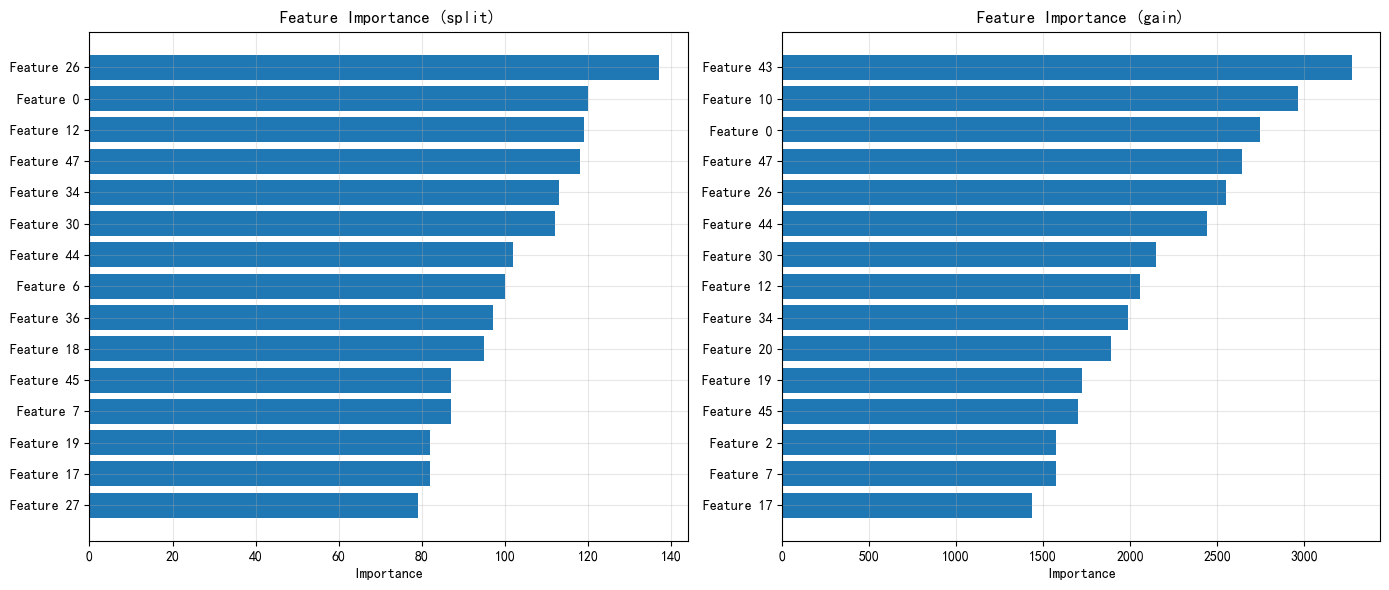


重要性类型:
----------------------------------------
split: 特征被用于分裂的次数
gain: 特征带来的总增益


In [6]:
print("\n特征重要性分析:")
print("=" * 60)

# 初始化LightGBM分类模型并训练
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# LightGBM两种主流特征重要性计算方式
importance_types = ['split', 'gain']

# 创建1行2列画布，尺寸宽14高6，用于并排绘制两种重要性图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 循环分别绘制split、gain两种特征重要性
for idx, imp_type in enumerate(importance_types):
    # 判断重要性类型，获取对应分数
    if imp_type == 'split':
        # split：直接调用封装好的属性，代表特征分裂总次数
        importance = lgb_model.feature_importances_
    else:
        # gain：通过底层booster获取，代表特征带来的总分裂增益
        importance = lgb_model.booster_.feature_importance(importance_type='gain')

    # 对重要性分数升序排序，取后15个，即得分最高的Top15特征下标
    top_indices = np.argsort(importance)[-15:]

    # 绘制横向柱状图，y轴0~15，x轴为对应特征重要性分数
    axes[idx].barh(range(15), importance[top_indices])
    # 设置y轴刻度位置
    axes[idx].set_yticks(range(15))
    # y轴刻度标签：Feature + 原始特征编号
    axes[idx].set_yticklabels([f'Feature {i}' for i in top_indices])
    # x轴名称
    axes[idx].set_xlabel('Importance')
    # 子图标题，标注当前重要性类型
    axes[idx].set_title(f'Feature Importance ({imp_type})')
    # 显示网格，透明度0.3，便于读数
    axes[idx].grid(True, alpha=0.3)

# 自动调整子图间距，防止文字重叠
plt.tight_layout()
# 展示绘制完成的两张特征重要性图
plt.show()

# 打印两种指标文字说明
print("\n重要性类型:")
print("-" * 40)
print("split: 特征被用于分裂的次数")
print("gain: 特征带来的总增益")

---

## 七、超参数调优

参数调得好，模型性能上一个台阶。下面我们跟上一篇一样，还是用随机搜索（Randomized Search），来对 LightGBM 模型进行自动化超参数调优的完整工程实践。

**主要步骤（仔细看代码和注释！）：**
1. 针对性构建参数搜索空间
   - 启用 GOSS 算法：将 boosting_type 设为 ['goss']（One-Side Gradient Sampling）。这是 LightGBM 的核心黑科技之一，通过保留大梯度样本并随机采样小梯度样本，能在不损失精度的前提下大幅提升训练速度。
   - 规避 GOSS 冲突：由于 GOSS 机制自带采样逻辑，代码中明确将 subsample 锁定为 [1.0]，并加了注释提醒，防止因参数冲突导致运行报错。
   - 控制 Leaf-wise 风险：LightGBM 采用叶子生长策略，容易长出过深的树导致过拟合。代码特意限制了 max_depth（去掉了无限制的 -1），并加入了 min_child_samples 等正则化参数来约束模型复杂度。
2. 高效的随机搜索策略
   设定 n_iter=15 进行 15 次随机抽样试验；采用 3 折交叉验证（cv=3）和准确率（accuracy）作为评估标准
3. 多核并行加速
   在初始化基础模型时设置了 n_jobs=1，但在 RandomizedSearchCV 中设置了 n_jobs=-1。这种配置意味着调优框架将调用机器所有的 CPU 核心，同时并行跑多个参数组合的交叉验证任务，极大缩短了搜索时间
4. 最优参数提取与测试集验证
   搜索完成后，自动打印出表现最好的参数组合（best_params_）及其在交叉验证中的最高得分（best_score_）

In [8]:
print("\nLightGBM超参数调优:")
print("=" * 60)

# 导入随机搜索工具，用于大范围超参快速寻优
from sklearn.model_selection import RandomizedSearchCV

# 定义超参数随机搜索空间，本次使用GOSS加速训练算法
param_dist = {
    'boosting_type': ['goss'],  # 提升树类型固定为goss，基于梯度单边采样，大幅提速
    'num_leaves': [20, 31, 50], # 单树最大叶子节点，控制模型复杂度
    'max_depth': [5, 7, 10],    # 限制树最大深度，避免Leaf-wise生长无限制导致过拟合
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # 学习率梯度步长
    'n_estimators': [100, 200], # 决策树总数量
    'min_child_samples': [10, 20, 50], # 叶子节点最少样本数，抑制过拟合
    'subsample': [1.0],         # GOSS算法强制要求样本采样比例为1，修改会直接报错
    'colsample_bytree': [0.8, 0.9, 1.0], # 每棵树随机采样特征比例
    'reg_alpha': [0, 0.1, 0.5], # L1正则系数，增大提升特征稀疏性
    'reg_lambda': [0, 0.1, 0.5] # L2正则系数，防止权重过大过拟合
}

# 遍历打印全部待搜索参数与候选取值
print("参数搜索空间:")
for param, values in param_dist.items():
    print(f"  {param}: {values}")

# 构建基础LightGBM模型，作为调优载体
# n_jobs=1：模型内部关闭多线程，避免和外部搜索并行冲突
lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1,n_jobs=1)

# 初始化随机搜索器
random_search = RandomizedSearchCV(
    lgb_base, param_dist,
    n_iter=15,   # 随机抽取15组参数组合测试，相比网格搜索速度更快
    cv=3,        # 3折交叉验证评估每组参数效果
    scoring='accuracy', # 以准确率作为模型优劣评判指标
    n_jobs=-1,  # 使用全部CPU并行跑不同参数组合，加速搜索
    random_state=42, # 固定随机种子，调优结果可复现
    verbose=1        # 打印搜索进度日志
)

# 提示文字，开始执行超参搜索
print("\n开始随机搜索...")
# 在训练集上完成随机搜索、交叉验证
random_search.fit(X_train, y_train)

# 循环输出搜索得到的最优一组超参数
print(f"\n最优参数:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

# 输出最优参数对应的3折交叉验证平均准确率，保留4位小数
print(f"\n最优交叉验证得分: {random_search.best_score_:.4f}")

# 提取训练完成的最优LightGBM模型
best_lgb = random_search.best_estimator_
# 使用最优模型在独立测试集预测
y_pred_best = best_lgb.predict(X_test)
# 计算并打印测试集泛化准确率
print(f"测试集准确率: {accuracy_score(y_test, y_pred_best):.4f}")


LightGBM超参数调优:
参数搜索空间:
  boosting_type: ['goss']
  num_leaves: [20, 31, 50]
  max_depth: [5, 7, 10]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  n_estimators: [100, 200]
  min_child_samples: [10, 20, 50]
  subsample: [1.0]
  colsample_bytree: [0.8, 0.9, 1.0]
  reg_alpha: [0, 0.1, 0.5]
  reg_lambda: [0, 0.1, 0.5]

开始随机搜索...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

最优参数:
  subsample: 1.0
  reg_lambda: 0.1
  reg_alpha: 0
  num_leaves: 50
  n_estimators: 200
  min_child_samples: 10
  max_depth: 10
  learning_rate: 0.2
  colsample_bytree: 0.9
  boosting_type: goss

最优交叉验证得分: 0.9584
测试集准确率: 0.9675


---

## 八、综合实战：加州房价预测

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来。这里我们还是用第44篇和第46篇用过的加州房价数据（cal_housing.tgz），使用 LightGBM 处理结构化数据的回归任务。

主要步骤：

1. 数据加载与划分
2. 回归模型构建与正则化配置
   - 实例化了 LGBMRegressor 回归模型，设置了较小的学习率（learning_rate=0.05）配合较多的树数量（n_estimators=500），以获得更精细的拟合效果。
   - 通过 num_leaves=50 和 max_depth=8 控制叶子生长策略下的模型复杂度，同时引入 subsample=0.8 和 colsample_bytree=0.8 进行行列采样，有效防止模型过拟合。
3. 验证集拆分与早停机制 (Early Stopping)
   如果连续 20 轮验证集的评估指标没有改善，训练将自动终止，从而精准锁定最优的树数量。
4. 精准预测与多维度评估
   在调用 predict 时，显式传入了 num_iteration=lgb_reg.best_iteration_，确保使用的是早停机制找到的最佳模型进行预测

In [5]:
print(" 综合实战：加州房价预测（回归任务）")

# 指定数据集本地存放目录
data_dir = '../my_custom_data_folder'
# 加载sklearn内置加州房价数据集，数据保存到自定义路径
housing = fetch_california_housing(data_home=data_dir)
# 拆分特征矩阵X与房价标签y（回归连续值）
X_house, y_house = housing.data, housing.target

# 整体数据集划分：训练集80%，测试集20%，固定随机种子保证可复现
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42)

# 输出特征总数量
print(f"特征数: {X_house.shape[1]}")
# 打印全部特征名称
print(f"特征: {housing.feature_names}")
# 说明预测目标含义
print(f"目标: 房价中位数（万美元）")

# 初始化LightGBM回归模型 LGBMRegressor用于连续值预测
lgb_reg = lgb.LGBMRegressor(
    n_estimators=500,        # 最大迭代树数量
    learning_rate=0.05,      # 学习率，小学习率搭配更多树提升精度
    num_leaves=50,           # 单棵树最大叶子节点，控制模型复杂度
    max_depth=8,             # 限制树深度，防止过拟合
    subsample=0.8,           # 每棵树随机采样80%样本
    colsample_bytree=0.8,    # 每棵树随机采样80%特征
    random_state=42,         # 固定随机种子
    verbose=-1               # 关闭训练日志输出
)

# 从原有训练集中再拆分出训练子集+独立验证集，用于早停判断
X_train_h_sub, X_val_h, y_train_h_sub, y_val_h = train_test_split(
    X_train_h, y_train_h, test_size=0.2, random_state=42)

# 模型训练，传入验证集并启用回调早停
lgb_reg.fit(
    X_train_h_sub, y_train_h_sub,
    eval_set=[(X_val_h, y_val_h)],  # 指定监控的验证集
    # 回调1：早停，验证集指标连续20轮无提升则停止；回调2：关闭迭代打印
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)]
)

# 在测试集做预测，仅使用早停筛选出的最优迭代轮数，规避过拟合
y_pred_h = lgb_reg.predict(X_test_h, num_iteration=lgb_reg.best_iteration_)

# 回归评估指标计算
# MSE均方误差：预测值与真实值差值平方的均值
mse = mean_squared_error(y_test_h, y_pred_h)
# RMSE均方根误差：MSE开根号，单位和房价保持一致，直观易懂
rmse = np.sqrt(mse)

# 输出模型评估结果
print(f"\n模型性能:")
print("-" * 40)
# 输出早停得到的最优树数量
print(f"最优迭代次数: {lgb_reg.best_iteration_}")
# 打印RMSE，保留4位小数
print(f"RMSE: {rmse:.4f}")
# MAE平均绝对误差：预测与真实差值绝对值的均值，对异常值更稳健
print(f"MAE: {np.mean(np.abs(y_test_h - y_pred_h)):.4f}")

 综合实战：加州房价预测（回归任务）
特征数: 8
特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标: 房价中位数（万美元）
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 0.215328

模型性能:
----------------------------------------
最优迭代次数: 500
RMSE: 0.4401
MAE: 0.2877


- RMSE (0.4401)：均方根误差对大误差敏感。0.44 的数值意味着在考虑了少数预测偏差较大的样本后，模型的总体波动控制在可接受范围内。
- MAE (0.2877)：平均绝对误差更接近业务直觉。它表示模型预测的房价平均偏离真实值约 0.29 万美元（即 2900 美元左右）。对于均价在 2-3 万美元的数据集来说，这是一个相当不错的精度。

模型评估完毕，画图看看预测值和真实值的对比：


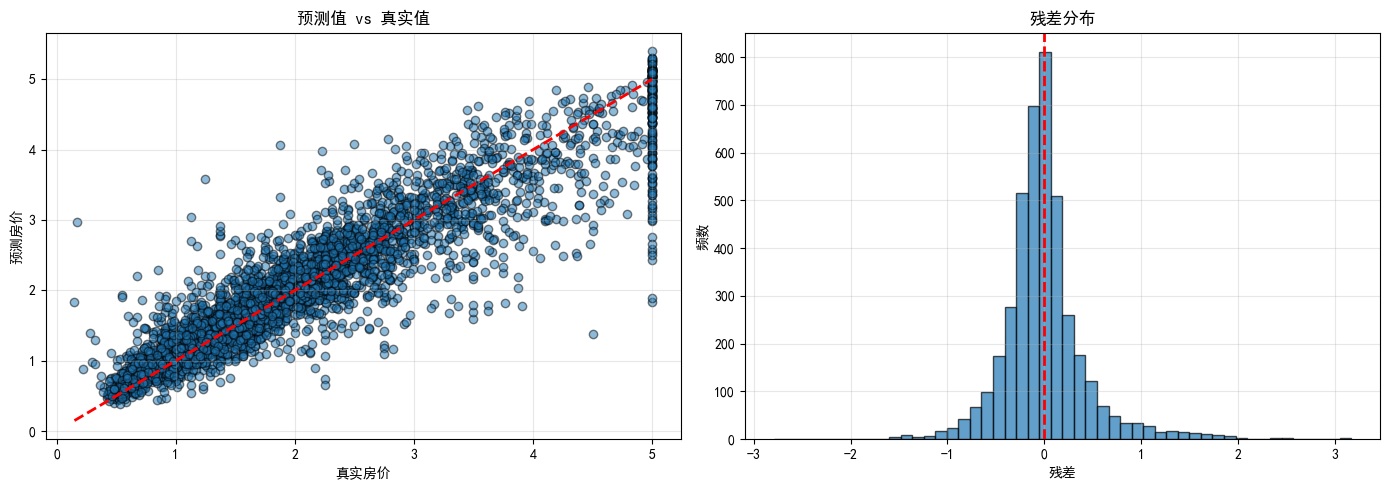

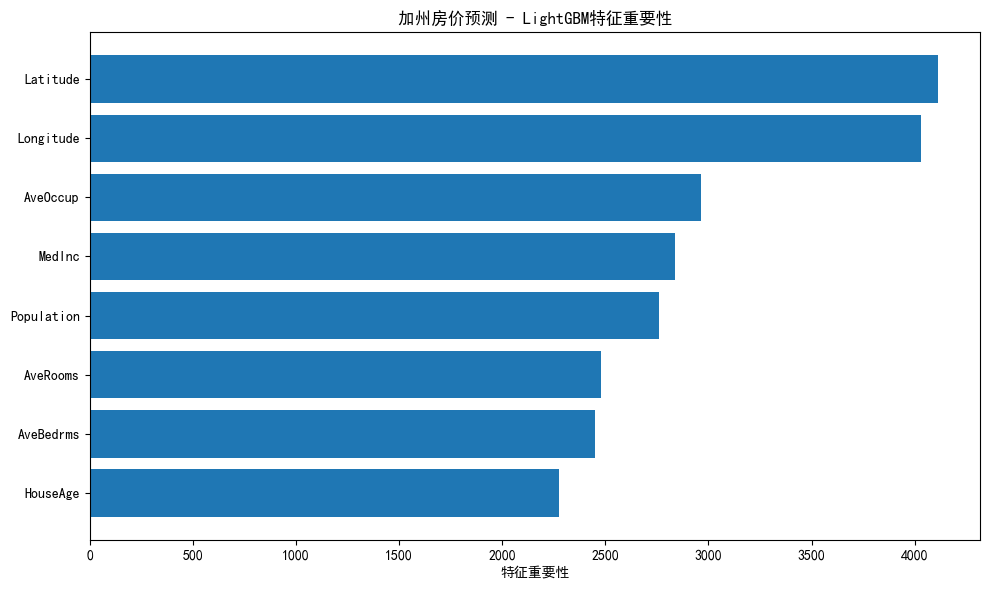

In [4]:
# 可视化结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 预测 vs 真实
axes[0].scatter(y_test_h, y_pred_h, alpha=0.5, edgecolors='k')
axes[0].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
axes[0].set_xlabel('真实房价')
axes[0].set_ylabel('预测房价')
axes[0].set_title('预测值 vs 真实值')
axes[0].grid(True, alpha=0.3)

# 残差分布
residuals = y_test_h - y_pred_h
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('残差')
axes[1].set_ylabel('频数')
axes[1].set_title('残差分布')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 特征重要性
plt.figure(figsize=(10, 6))
importance_h = pd.DataFrame({
    'feature': housing.feature_names,
    'importance': lgb_reg.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(importance_h['feature'], importance_h['importance'])
plt.xlabel('特征重要性')
plt.title('加州房价预测 - LightGBM特征重要性')
plt.tight_layout()
plt.show()


图形解读：

1. 预测值 vs 真实值
   - 整体趋势：数据点紧密围绕红色对角线（理想预测线）分布，表明模型的预测值与真实房价之间存在极强的正相关性。模型成功捕捉到了房价的主要变化规律。
   - 高价值区间偏差：观察右上角（房价 > 4.5 万美元/10k），可以看到明显的“截断”现象。许多高价房的预测值低于真实值（点位于红线下方）。这是该数据集的典型特征（目标变量存在上限 5.0），导致模型难以准确拟合极值区域。
2. 残差分布直方图
   - 中心性：残差（预测值 - 真实值）的分布呈现标准的钟形曲线，且峰值高度集中在 0 附近（红色虚线处）。这意味着大多数预测误差非常小，模型没有明显的系统性偏差（即没有普遍的高估或低估）
   - 长尾效应：虽然主体对称，但右侧（正残差）存在轻微的长尾。这对应了左图中部分样本被严重低估的情况（通常发生在高价房区域），提示我们在处理极端值时模型仍有提升空间。

---

## 九、LightGBM调参指南

调参是有套路的，来学一学：

第1步：确定基础参数
  - learning_rate=0.1
  - n_estimators=1000（配合早停）
  - 用early_stopping找到最优迭代次数

第2步：调整树结构
  - num_leaves: 主要控制复杂度
    - 小数据集: 20-50
    - 大数据集: 50-150
  - max_depth: 限制树深度，防止过拟合
    - 通常5-10，或-1不限制

第3步：调整正则化
  - min_child_samples: 根据数据量调整
    - 小数据: 10-50
    - 大数据: 100-1000
  - reg_lambda: 1-10
  - reg_alpha: 0-1

第4步：调整采样
  - feature_fraction: 0.8-1.0
  - bagging_fraction: 0.8-1.0
  - bagging_freq: 5

第5步：降低学习率
  - learning_rate: 0.01-0.05
  - 相应增加n_estimators

【快速调参模板】

小数据集 (<10K):
  num_leaves=20, max_depth=5, min_child_samples=20

中数据集 (10K-100K):
  num_leaves=31, max_depth=6-8, min_child_samples=20-50

大数据集 (>100K):
  num_leaves=50-100, max_depth=-1, min_child_samples=100+

---

## 十、小结

| 参数 | 作用 | 建议值 |
|------|------|--------|
| **num_leaves** | 叶子节点数 | 20-150 |
| **max_depth** | 树深度 | 5-10 |
| **learning_rate** | 学习率 | 0.01-0.1 |
| **n_estimators** | 树数量 | 100-1000 |
| **min_child_samples** | 最小样本数 | 20-1000 |
| **feature_fraction** | 特征采样 | 0.8-1.0 |
| **bagging_fraction** | 样本采样 | 0.8-1.0 |

**LightGBM vs XGBoost 对比总结**：

| 特性 | LightGBM | XGBoost |
|------|----------|---------|
| 训练速度 | ⚡ 更快 | 快 |
| 内存占用 | 💾 更低 | 低 |
| 准确率 | 🎯 相当 | 高 |
| 类别特征 | ✅ 原生支持 | 需编码 |
| 树生长 | Leaf-wise | Level-wise |
| 算法 | 直方图 | 预排序 |

**选择建议**：
- 大规模数据 → LightGBM
- 需要类别特征支持 → LightGBM
- 追求极致速度 → LightGBM
- 小数据/比赛 → 两者都可以

---

## 十一、课后练习

1. 对比LightGBM和XGBoost在不同数据规模下的性能
2. 调整num_leaves和max_depth，观察对过拟合的影响
3. 用LightGBM完成一个多分类任务
4. 尝试LightGBM的类别特征支持（如果有类别数据）

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 59 篇：特征重要性与模型可解释性 SHAP**
>
> 下篇学 SHAP 模型可解释性——揭开黑盒模型的神秘面纱，让你知道模型到底是根据什么做出的决策。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*
